# Hotel booking analysis

### Dataset Overview

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Machine Learning/Final Project/hotel_bookings.csv")
print("Raw shape:", df.shape)
display(df.head(3))

Raw shape: (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,meal,country,market_segment,distribution_channel,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,3,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,0.0,0,BB,PRT,Direct,Direct,0,0,0,C,C,4,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,0.0,0,BB,GBR,Direct,Direct,0,0,0,A,C,0,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02


In [ ]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

None

In [ ]:
display(df.isna().sum().sort_values(ascending=False).head(15))

,0
company,112593
agent,16340
country,488
children,4
arrival_date_month,0
arrival_date_week_number,0
hotel,0
is_canceled,0
stays_in_weekend_nights,0
arrival_date_day_of_month,0


In [ ]:
display(df["is_canceled"].value_counts())
print("Cancellation rate:", round(df["is_canceled"].mean(), 4))

,count
is_canceled,
0,75166
1,44224


Cancellation rate: 0.3704


### Data Cleaning

In [ ]:
df_clean = df.copy()
print("Raw shape:", df_clean.shape)

Raw shape: (119390, 32)


In [ ]:
# children: a few missing values -> treat as 0
df_clean["children"] = df_clean["children"].fillna(0)

# country: small amount missing -> label as "Unknown"
df_clean["country"] = df_clean["country"].fillna("Unknown")

# agent/company: many missing values -> interpret as "no agent/company"
# use 0 to represent "none"
df_clean["agent"] = df_clean["agent"].fillna(0).astype(int)
df_clean["company"] = df_clean["company"].fillna(0).astype(int)

print("Top missing values:")
display(df_clean.isna().sum().sort_values(ascending=False).head(10))

Top missing values:


,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


In [ ]:
# Remove target leakage columns
leak_cols = ["reservation_status", "reservation_status_date"]
df_clean = df_clean.drop(columns=[c for c in leak_cols if c in df_clean.columns])

print("Removed columns:", leak_cols)
print("Current shape:", df_clean.shape)

Removed columns: ['reservation_status', 'reservation_status_date']
Current shape: (119390, 30)


In [ ]:
# Remove invalid guest records
before = df_clean.shape[0]

invalid_mask = (df_clean["adults"] == 0) & (df_clean["children"] == 0) & (df_clean["babies"] == 0)
df_clean = df_clean[~invalid_mask].copy()

after = df_clean.shape[0]
print("Removed rows (all guests = 0):", before - after)
print("Current shape:", df_clean.shape)

Removed rows (all guests = 0): 180
Current shape: (119210, 30)


In [ ]:
# Fix obvious numeric issues
neg_adr_count = (df_clean["adr"] < 0).sum()
print("Negative ADR count (before):", neg_adr_count)

# Set negative ADR to 0
df_clean.loc[df_clean["adr"] < 0, "adr"] = 0

print("Negative ADR count (after):", (df_clean["adr"] < 0).sum())

Negative ADR count (before): 1
Negative ADR count (after): 0


In [ ]:
# Ensure target is int
df_clean["is_canceled"] = df_clean["is_canceled"].astype(int)

# children becomes int after fillna(0)
df_clean["children"] = df_clean["children"].astype(int)

# Treat agent/company as categorical IDs
df_clean["agent"] = df_clean["agent"].astype(str)
df_clean["company"] = df_clean["company"].astype(str)

print(df_clean[["children","agent","company","is_canceled"]].dtypes)

children        int64
agent          object
company        object
is_canceled     int64
dtype: object


In [ ]:
# Final validation summary
print("Final shape:", df_clean.shape)
print("Final cancellation rate:", round(df_clean["is_canceled"].mean(), 4))

print("Remaining missing values:")
display(df_clean.isna().sum().sort_values(ascending=False).head(10))

Final shape: (119210, 30)
Final cancellation rate: 0.3708
Remaining missing values:


,0
hotel,0
is_canceled,0
lead_time,0
arrival_date_year,0
arrival_date_month,0
arrival_date_week_number,0
arrival_date_day_of_month,0
stays_in_weekend_nights,0
stays_in_week_nights,0
adults,0


### Future Engineering

In [ ]:
# Total stay nights
df_clean["total_stay_nights"] = df_clean["stays_in_weekend_nights"] + df_clean["stays_in_week_nights"]

# Total guests
df_clean["total_guests"] = df_clean["adults"] + df_clean["children"] + df_clean["babies"]

# Family/children
df_clean["has_children"] = ((df_clean["children"] + df_clean["babies"]) > 0).astype(int)
df_clean["is_family"] = (df_clean["total_guests"] >= 3).astype(int)

# Log transform for skewed lead_time
df_clean["lead_time_log1p"] = np.log1p(df_clean["lead_time"])

df_clean["room_changed"] = (df_clean["reserved_room_type"] != df_clean["assigned_room_type"]).astype(int)

# Sanity check
new_cols = ["total_stay_nights","total_guests","has_children","is_family","lead_time_log1p","room_changed"]
display(df_clean[new_cols].head(5))

,total_stay_nights,total_guests,has_children,is_family,lead_time_log1p,room_changed
0,0,2,0,0,5.837730,0
1,0,2,0,0,6.603944,0
2,1,1,0,0,2.079442,1
3,1,1,0,0,2.639057,0
4,2,2,0,0,2.708050,0


### EDA

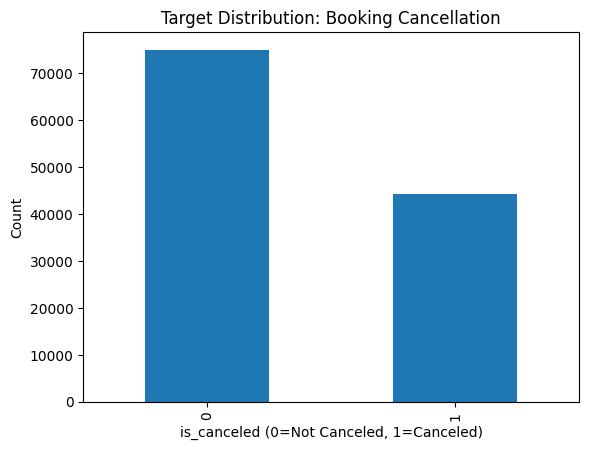

Overall cancellation rate: 0.3708


In [ ]:
# Cancellation rate
cancel_rate = df_clean["is_canceled"].mean()

plt.figure()
df_clean["is_canceled"].value_counts().plot(kind="bar")
plt.title("Target Distribution: Booking Cancellation")
plt.xlabel("is_canceled (0=Not Canceled, 1=Canceled)")
plt.ylabel("Count")
plt.show()

print("Overall cancellation rate:", round(cancel_rate, 4))

<Figure size 640x480 with 0 Axes>

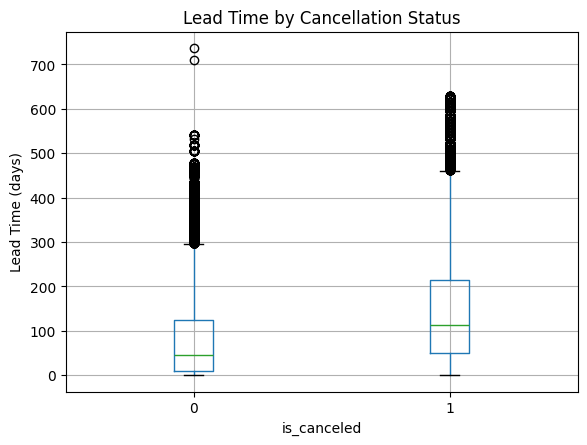

In [ ]:
# Lead time distribution
plt.figure()
df_clean.boxplot(column="lead_time", by="is_canceled")
plt.title("Lead Time by Cancellation Status")
plt.suptitle("")
plt.xlabel("is_canceled")
plt.ylabel("Lead Time (days)")
plt.show()

<Figure size 640x480 with 0 Axes>

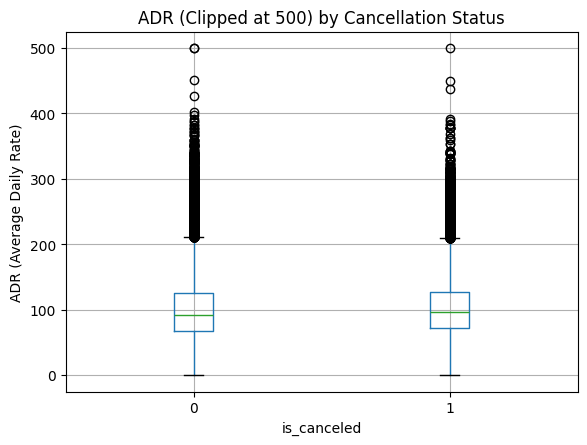

In [ ]:
# Clip extreme ADR values for clearer visualization
tmp = df_clean.copy()
tmp["adr_clip"] = tmp["adr"].clip(upper=500)

plt.figure()
tmp.boxplot(column="adr_clip", by="is_canceled")
plt.title("ADR (Clipped at 500) by Cancellation Status")
plt.suptitle("")
plt.xlabel("is_canceled")
plt.ylabel("ADR (Average Daily Rate)")
plt.show()

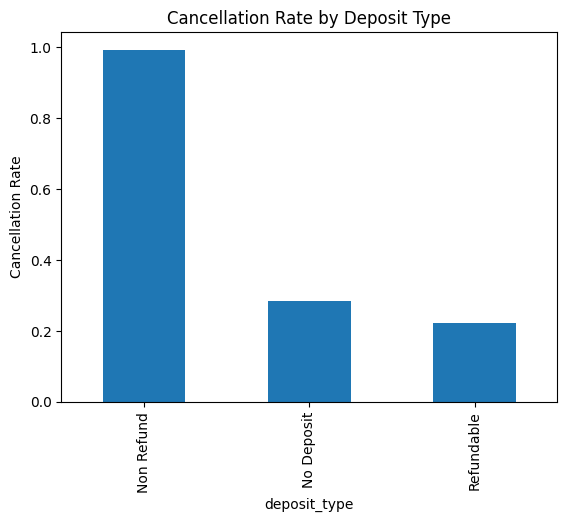

In [ ]:
# Deposit type cancellation rate
rate_by_dep = df_clean.groupby("deposit_type")["is_canceled"].mean().sort_values(ascending=False)
rate_by_dep.plot(kind="bar")
plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("deposit_type")
plt.ylabel("Cancellation Rate")
plt.show()

In [ ]:
# Drop deposit_type to avoid near-deterministic relationship with cancellation
if "deposit_type" in df_clean.columns:
    df_clean = df_clean.drop(columns=["deposit_type"])

print("Current shape:", df_clean.shape)

Current shape: (119210, 35)


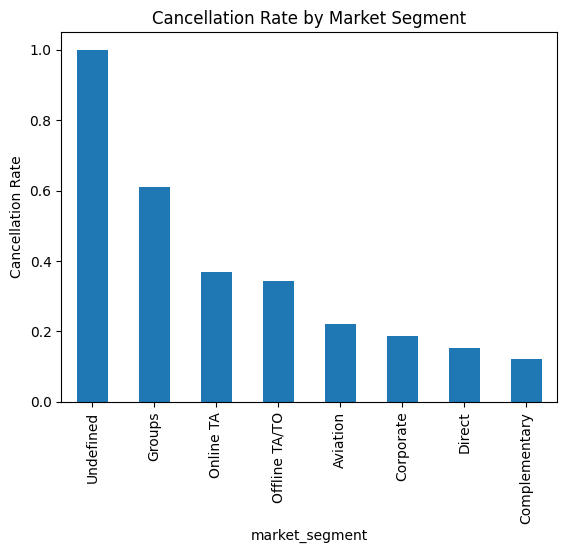

In [ ]:
# Market segment cancellation rate
rate_by_seg = df_clean.groupby("market_segment")["is_canceled"].mean().sort_values(ascending=False)
rate_by_seg.plot(kind="bar")
plt.title("Cancellation Rate by Market Segment")
plt.xlabel("market_segment")
plt.ylabel("Cancellation Rate")
plt.show()

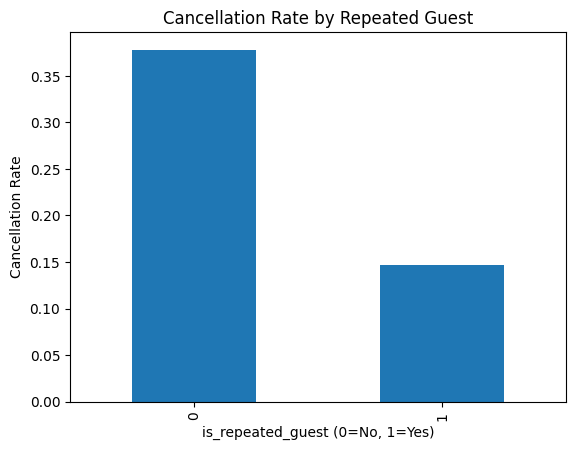

In [ ]:
# Repeated guest cancellation rate
rate_by_rep = df_clean.groupby("is_repeated_guest")["is_canceled"].mean()
rate_by_rep.plot(kind="bar")
plt.title("Cancellation Rate by Repeated Guest")
plt.xlabel("is_repeated_guest (0=No, 1=Yes)")
plt.ylabel("Cancellation Rate")
plt.show()

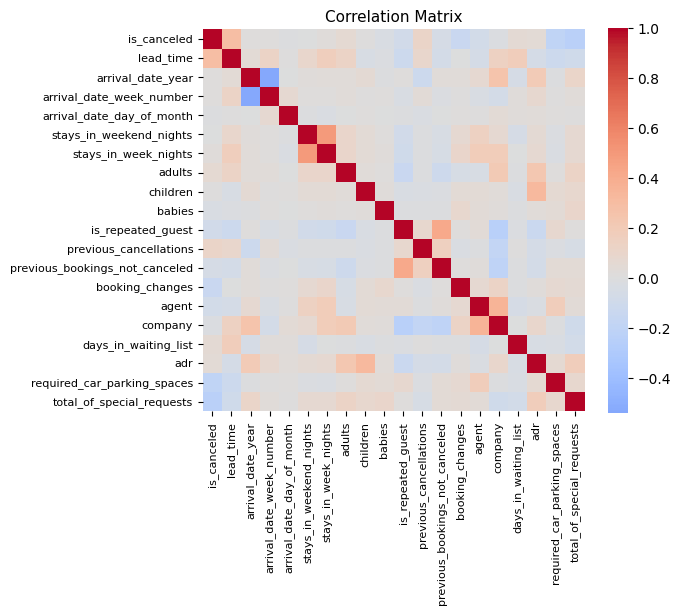

In [ ]:
corr_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(7,6))

sns.heatmap(corr_matrix,
            cmap="coolwarm",
            center=0,
            square=True)

plt.title("Correlation Matrix", fontsize=11)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

## Feature Engineering

In [ ]:
target_col = "is_canceled"

X = df_clean.drop(columns=[target_col])
y = df_clean[target_col]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

Feature matrix shape: (119210, 34)
Target shape: (119210,)


In [ ]:
# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numeric features:", len(numeric_cols))
print("Categorical features:", len(categorical_cols))

Numeric features: 23
Categorical features: 11


In [ ]:
# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (95368, 34)
Test shape: (23842, 34)


In [ ]:
# Numeric transformer
numeric_transformer = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# Categorical transformer
categorical_transformer = Pipeline(steps=[
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

In [ ]:
# Fit only on training data
preprocessor.fit(X_train)

# Transform both sets
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Processed train shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed train shape: (95368, 899)
Processed test shape: (23842, 899)


X_train_svd shape: (95368, 30)
Explained variance: 0.913920673553007


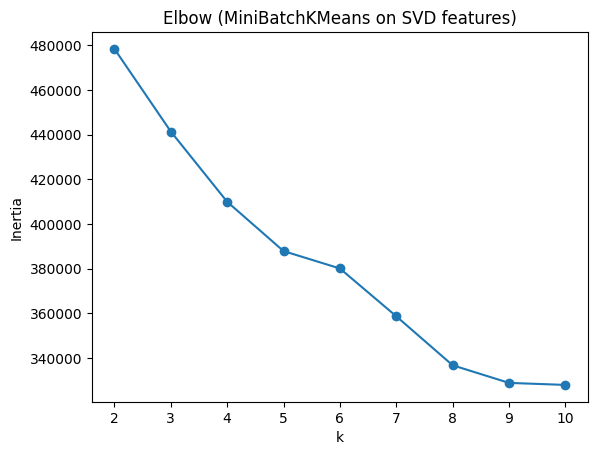

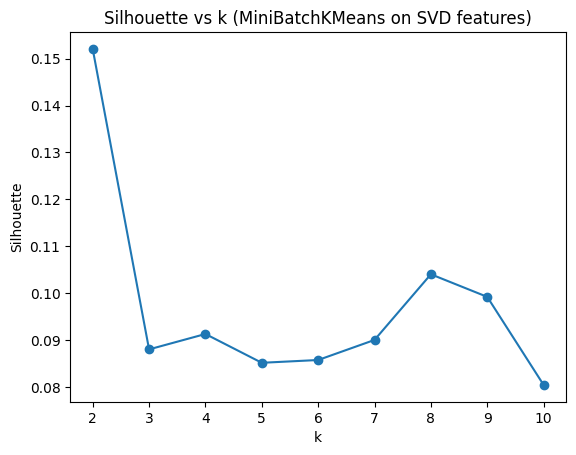

Best k by silhouette: 2


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

svd_dim = 30
svd = TruncatedSVD(n_components=svd_dim, random_state=42)

X_train_svd = svd.fit_transform(X_train_processed)
print("X_train_svd shape:", X_train_svd.shape)
print("Explained variance:", svd.explained_variance_ratio_.sum())

np.random.seed(42)
n_sample = min(20000, X_train_svd.shape[0])
idx = np.random.choice(X_train_svd.shape[0], n_sample, replace=False)
X_sample = X_train_svd[idx]

# 2) Elbow + Silhouette
ks = list(range(2, 11))
inertias, sil_scores = [], []

for k in ks:
    km = MiniBatchKMeans(
        n_clusters=k,
        random_state=42,
        batch_size=4096,
        n_init=10
    )
    km.fit(X_sample)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_sample, km.labels_))

plt.figure()
plt.plot(ks, inertias, marker="o")
plt.title("Elbow (MiniBatchKMeans on SVD features)")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.show()

plt.figure()
plt.plot(ks, sil_scores, marker="o")
plt.title("Silhouette vs k (MiniBatchKMeans on SVD features)")
plt.xlabel("k")
plt.ylabel("Silhouette")
plt.show()

best_k = ks[int(np.argmax(sil_scores))]
print("Best k by silhouette:", best_k)

In [ ]:
final_kmeans = MiniBatchKMeans(
    n_clusters=best_k,
    random_state=42,
    batch_size=4096,
    n_init=20
)
final_kmeans.fit(X_train_svd)

# transform test
X_test_svd = svd.transform(X_test_processed)

train_clusters = final_kmeans.predict(X_train_svd)
test_clusters = final_kmeans.predict(X_test_svd)

print("Train cluster counts:", np.bincount(train_clusters))
print("Test cluster counts:", np.bincount(test_clusters))

Train cluster counts: [87923  7445]
Test cluster counts: [21927  1915]


In [ ]:
X_all = df_clean.drop(columns=["is_canceled"])
X_all_processed = preprocessor.transform(X_all)
X_all_svd = svd.transform(X_all_processed)
all_clusters = final_kmeans.predict(X_all_svd)

df_profile = df_clean.copy()
df_profile["cluster"] = all_clusters

cluster_summary = df_profile.groupby("cluster").agg(
    n=("cluster", "count"),
    cancel_rate=("is_canceled", "mean"),
    avg_lead_time=("lead_time", "mean"),
    avg_adr=("adr", "mean"),
    avg_total_stay=("total_stay_nights", "mean"),
    repeat_rate=("is_repeated_guest", "mean"),
    avg_special_req=("total_of_special_requests", "mean")
).sort_values("cancel_rate", ascending=False)

display(cluster_summary)

,n,cancel_rate,avg_lead_time,avg_adr,avg_total_stay,repeat_rate,avg_special_req
cluster,,,,,,,
0,109850,0.372553,105.408894,97.410087,3.382431,0.033318,0.541029
1,9360,0.349786,88.856197,155.474760,3.940491,0.010150,0.929167


In [ ]:
# market segment composition
segment_dist = pd.crosstab(
    df_profile["cluster"],
    df_profile["market_segment"],
    normalize="index"
)
display(segment_dist)

# distribution channel
channel_dist = pd.crosstab(
    df_profile["cluster"],
    df_profile["distribution_channel"],
    normalize="index"
)
display(channel_dist)

# hotel type
hotel_dist = pd.crosstab(
    df_profile["cluster"],
    df_profile["hotel"],
    normalize="index"
)
display(hotel_dist)

market_segment,Aviation,Complementary,Corporate,Direct,Groups,Offline TA/TO,Online TA,Undefined
cluster,,,,,,,,
0,0.002139,0.006090,0.047638,0.098216,0.179636,0.213546,0.452717,0.000018
1,0.000000,0.006303,0.005235,0.191560,0.006197,0.077350,0.713355,0.000000


distribution_channel,Corporate,Direct,GDS,TA/TO,Undefined
cluster,,,,,
0,0.060027,0.116149,0.001757,0.82203,0.000036
1,0.006090,0.197863,0.000000,0.79594,0.000107


hotel,City Hotel,Resort Hotel
cluster,,
0,0.671516,0.328484
1,0.576603,0.423397


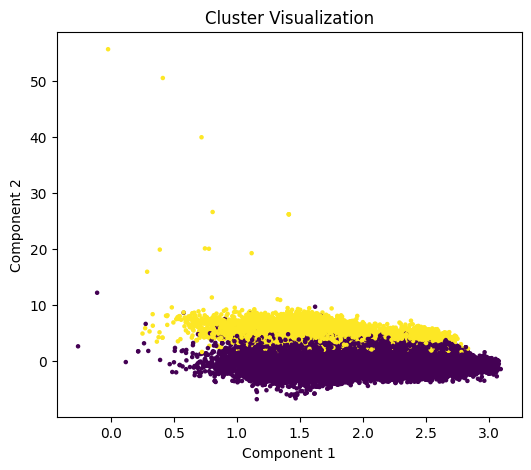

In [ ]:
plt.figure(figsize=(6,5))
plt.scatter(X_train_svd[:,0], X_train_svd[:,1], c=train_clusters, s=5)
plt.title("Cluster Visualization")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

## Supervised Learning

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, BaggingClassifier, GradientBoostingClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    ConfusionMatrixDisplay
)

In [ ]:
# Logistic regression

lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_processed, y_train)

lr_pred  = lr.predict(X_test_processed)
lr_proba = lr.predict_proba(X_test_processed)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, lr_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, lr_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

Accuracy: 0.8405
F1 Score: 0.7791
ROC-AUC: 0.9190


In [ ]:
# Decision tree
# Use cross-validation to find best max_depth
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
depth_scores = {}
for d in [3, 5, 7, 10, None]:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    score = cross_val_score(dt, X_train_processed, y_train,
                            cv=cv, scoring='roc_auc').mean()
    depth_scores[d] = score
    print(f"max_depth={str(d):5}; CV AUC: {score:.4f}")

best_depth = max(depth_scores, key=depth_scores.get)
print(f"\nBest depth: {best_depth}")

dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt.fit(X_train_processed, y_train)

dt_pred  = dt.predict(X_test_processed)
dt_proba = dt.predict_proba(X_test_processed)[:, 1]

print(f"Accuracy: {accuracy_score(y_test, dt_pred):.4f}")
print(f"F1 Score: {f1_score(y_test, dt_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, dt_proba):.4f}")

max_depth=3    ; CV AUC: 0.8480
max_depth=5    ; CV AUC: 0.8934
max_depth=7    ; CV AUC: 0.9147
max_depth=10   ; CV AUC: 0.9278
max_depth=None ; CV AUC: 0.8545

Best depth: 10
Accuracy: 0.8559
F1 Score: 0.7983
ROC-AUC: 0.9287


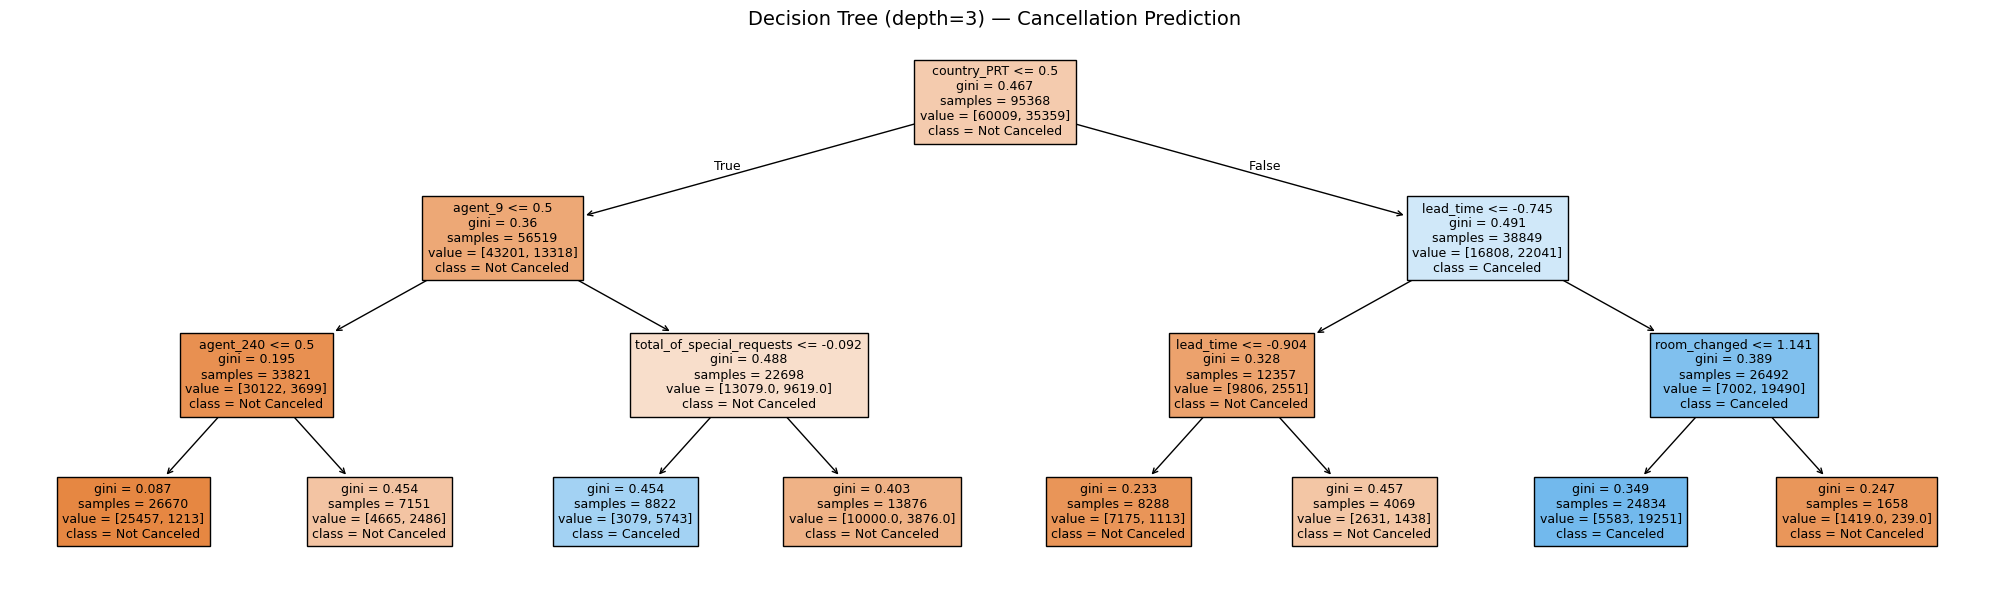

In [ ]:
# Visualize a shallow tree (depth=3) for interpretability
dt_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_viz.fit(X_train_processed, y_train)

# Get feature names after preprocessing
num_feature_names = numeric_cols
cat_feature_names = preprocessor.named_transformers_['cat']['onehot']\
                        .get_feature_names_out(categorical_cols).tolist()
all_feature_names = num_feature_names + cat_feature_names

plt.figure(figsize=(20, 6))
plot_tree(dt_viz,
          feature_names=all_feature_names,
          class_names=['Not Canceled', 'Canceled'],
          filled=True, max_depth=3, fontsize=9)
plt.title("Decision Tree (depth=3) — Cancellation Prediction", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Linear SVM
linear_svm = CalibratedClassifierCV(LinearSVC(C=1.0, max_iter=2000, random_state=42))
linear_svm.fit(X_train_processed, y_train)
svm_pred  = linear_svm.predict(X_test_processed)
svm_proba = linear_svm.predict_proba(X_test_processed)[:, 1]

print(f"Linear SVM Accuracy: {accuracy_score(y_test, svm_pred):.4f}")
print(f"Linear SVM F1: {f1_score(y_test, svm_pred):.4f}")
print(f"Linear SVM ROC-AUC: {roc_auc_score(y_test, svm_proba):.4f}")

Linear SVM Accuracy: 0.8394
Linear SVM F1: 0.7783
Linear SVM ROC-AUC: 0.9177


In [ ]:
# Random forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=10,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_processed, y_train)

rf_pred  = rf.predict(X_test_processed)
rf_proba = rf.predict_proba(X_test_processed)[:, 1]

print(f"Random Forest Accuracy: {accuracy_score(y_test, rf_pred):.4f}")
print(f"Random Forest F1: {f1_score(y_test, rf_pred):.4f}")
print(f"Random Forest ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")

Random Forest Accuracy: 0.8217
Random Forest F1: 0.7026
Random Forest ROC-AUC: 0.9199


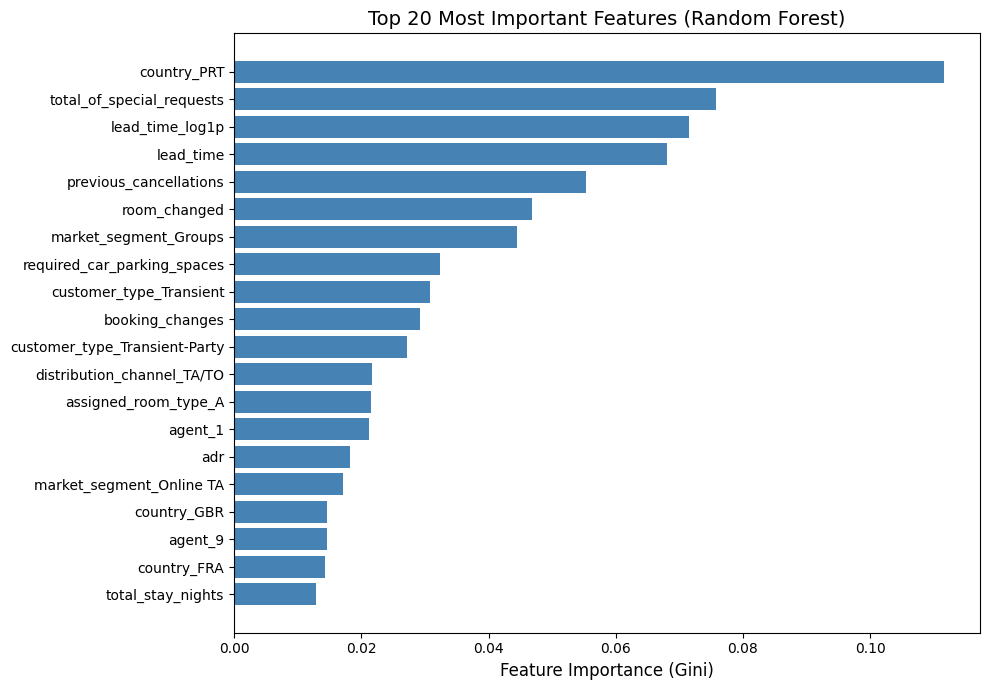

In [ ]:
# Feature importance
importances = rf.feature_importances_
feat_imp_df = pd.DataFrame({
    'feature': all_feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 7))
plt.barh(feat_imp_df['feature'][::-1], feat_imp_df['importance'][::-1], color='steelblue')
plt.xlabel("Feature Importance (Gini)", fontsize=12)
plt.title("Top 20 Most Important Features (Random Forest)", fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Bagging explicitly
bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(max_depth=10),
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
bagging.fit(X_train_processed, y_train)
bag_pred  = bagging.predict(X_test_processed)
bag_proba = bagging.predict_proba(X_test_processed)[:, 1]

print(f"Bagging DT Accuracy: {accuracy_score(y_test, bag_pred):.4f}")
print(f"Bagging DT F1: {f1_score(y_test, bag_pred):.4f}")
print(f"Bagging DT ROC-AUC: {roc_auc_score(y_test, bag_proba):.4f}")

Bagging DT Accuracy: 0.8623
Bagging DT F1: 0.8076
Bagging DT ROC-AUC: 0.9367


In [ ]:
# Gradient boosting
gb = GradientBoostingClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=5,
    subsample=0.8,
    random_state=42
)
gb.fit(X_train_processed, y_train)

gb_pred  = gb.predict(X_test_processed)
gb_proba = gb.predict_proba(X_test_processed)[:, 1]

print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, gb_pred):.4f}")
print(f"Gradient Boosting F1: {f1_score(y_test, gb_pred):.4f}")
print(f"Gradient Boosting ROC-AUC: {roc_auc_score(y_test, gb_proba):.4f}")

Gradient Boosting Accuracy: 0.8724
Gradient Boosting F1: 0.8234
Gradient Boosting ROC-AUC: 0.9466


In [ ]:
# Model comparison
models = {
    'Logistic Regression': (lr_pred, lr_proba),
    'Decision Tree':       (dt_pred, dt_proba),
    'Linear SVM':          (svm_pred, svm_proba),
    'Bagging':             (bag_pred, bag_proba),
    'Random Forest':       (rf_pred, rf_proba),
    'Gradient Boosting':   (gb_pred, gb_proba),
}

results = []
for name, (pred, proba) in models.items():
    results.append({
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_test, pred), 4),
        'Precision': round(precision_score(y_test, pred), 4),
        'Recall':    round(recall_score(y_test, pred), 4),
        'F1':        round(f1_score(y_test, pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_test, proba), 4),
    })

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(results_df.to_string(index=False))

              Model  Accuracy  Precision  Recall     F1  ROC-AUC
  Gradient Boosting    0.8724     0.8459  0.8020 0.8234   0.9466
            Bagging    0.8623     0.8380  0.7794 0.8076   0.9367
      Decision Tree    0.8559     0.8298  0.7690 0.7983   0.9287
      Random Forest    0.8217     0.9209  0.5680 0.7026   0.9199
Logistic Regression    0.8405     0.8010  0.7584 0.7791   0.9190
         Linear SVM    0.8394     0.7971  0.7603 0.7783   0.9177


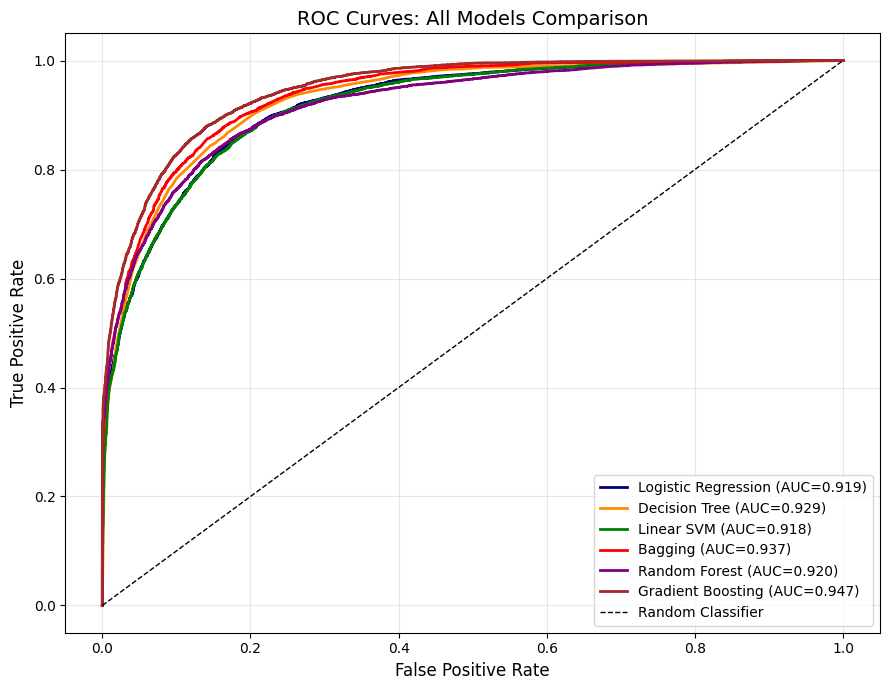

In [ ]:
# ROC curves for all models
plt.figure(figsize=(9, 7))
colors = ['navy', 'darkorange', 'green', 'red', 'purple', 'brown']

for (name, (_, proba)), color in zip(models.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, lw=2, color=color, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curves: All Models Comparison", fontsize=14)
plt.legend(loc='lower right', fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

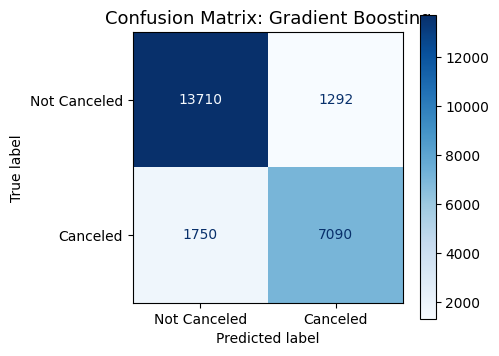

In [ ]:
# Confusion aatrix for best model
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, gb_pred,
    display_labels=['Not Canceled', 'Canceled'],
    cmap='Blues', ax=ax
)
plt.title("Confusion Matrix: Gradient Boosting", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Final model validation
train_proba_gb = gb.predict_proba(X_train_processed)[:, 1]
train_auc = roc_auc_score(y_train, train_proba_gb)
test_auc  = roc_auc_score(y_test, gb_proba)

print(f"Gradient Boosting Train AUC: {train_auc:.4f}")
print(f"Gradient Boosting Test AUC: {test_auc:.4f}")
print(f"Difference (overfit check): {train_auc - test_auc:.4f}")

Gradient Boosting Train AUC: 0.9538
Gradient Boosting Test AUC: 0.9466
Difference (overfit check): 0.0071
